# Análisis y procesamiento de señales

# Trabajo práctico N°1

### Ferreyra Valentina

En este trabajo práctico se implementaron y analizaron distintas señales utilizando Python.  Se generaron señales senoidales, ruido normal, ruido uniforme y una señal rectangular, trabajando siempre con 1000 muestras. 

Además, para cada caso se calculó y visualizó el módulo de la Transformada de Fourier, con el objetivo de observar cómo se representa cada señal en el dominio de la frecuencia.

In [201]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Punto 1

In [202]:
N = 1000
fs = 20000
k = 100
vmax = 1
dc = 0
ph = 0
f0 = k*(fs/N)


La frecuencia se obtiene a partir de f0 = k(fs/N). Como fs/N=20,Hz, tomando k=100 se obtiene una frecuencia de 2000\,Hz. La relación fs/f0=10 indica que se toman 10 muestras por cada período de la señal.

In [203]:
def mi_funcion_sen():

    n = np.arange(N) / fs 

    xx = dc + vmax * np.sin(2*np.pi*f0*n + ph)
    
    return (n,xx)

n,xx = mi_funcion_sen()

Se creó un vector de tiempo con los instantes en los que se toma cada muestra. Apartir de ese vector se generó la senoide usando la amplitud, frecuencia, componente continua y fase definidas anteriormente.

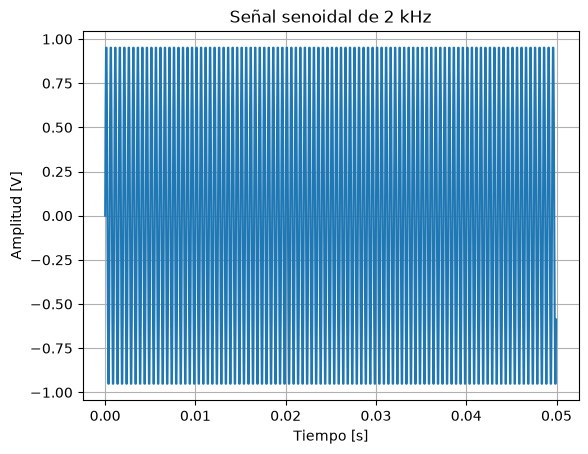

In [204]:
plt.figure()
plt.plot(n, xx)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal de 2 kHz")
plt.show()

En el gráfico se observan muchos períodos juntos porque las 1000 muestras representan aproximadamente 0.05 s de señal. En ese intervalo entran k = 100 períodos de la senoide 2 kHz.

Para analizar qué frecuencias forman la señal se calculó su DFT utilizando la FFT. La FFT permite obtener de forma eficiente los coeficientes de la Transformada Discreta de Fourier.

In [205]:
XX = np.fft.fft(xx)   # Representación de xx en el dominio de la frecuencia. La función fft toma esas 1000 muestras y calcula los coeficientes de la DFT

mod_XX = np.abs(XX) # El módulo es útil para visualizar un espectro: nos permite ver claramente dónde están las componentes importantes.

freq = np.fft.fftfreq(N, d=1/fs) # Construimos un vector de frecuencias

XX contiene los coeficientes de la DFT de la señal. Luego se calcula mod_XX, que corresponde al módulo de esos coeficientes y permite observar qué componentes de frecuencia tienen mayor presencia.
También se genera el vector freq, que relaciona cada posición de la DFT con su frecuencia correspondiente en Hz.

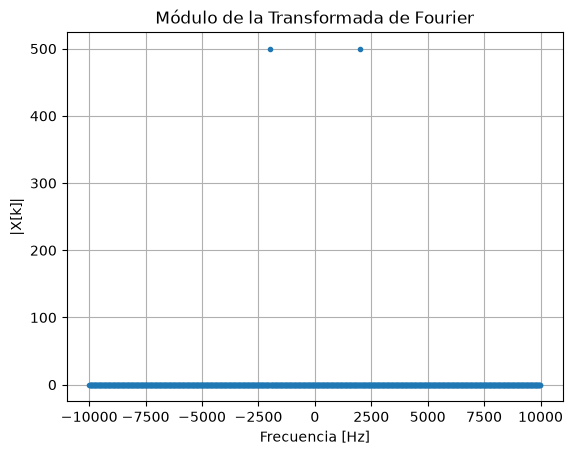

In [206]:
plt.figure()
plt.plot(freq, mod_XX, '.')
plt.title("Módulo de la Transformada de Fourier")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X[k]|")
plt.grid()
plt.show()

En el espectro se observan dos picos principales en +2000 Hz y -2000 Hz. Esto corresponde a la representación en frecuencia de una señal senoidal real, que presenta componentes en frecuencias positivas y negativas.
El resto de los valores se mantiene prácticamente en cero, ya que la señal generada es una senoide pura de 2 kHz.

PUNTO 2:

En este punto se mantiene la misma frecuencia de 2 kHz, pero se modifica la amplitud para obtener una potencia media de 2W y se agrega un desfase de pi/2.
Para una señal senoidal de valor medio cero, la potencia media se calcula como: P = (A)^2/2

In [207]:
N = 1000
fs = 20000
k = 100
vmax = 2
dc = 0
ph = np.pi/2

f0 = k*(fs/N)

In [208]:
def mi_funcion_sen():

    n = np.arange(N) / fs

    xx = dc + vmax * np.sin(2*np.pi*f0*n + ph)

    return n, xx

n, xx = mi_funcion_sen()

La frecuencia y la frecuencia de muestreo se mantienen iguales al punto anterior, por lo que se siguen teniendo 10 muestras por período. Los cambios que hice están únicamente en la amplitud y la fase de la señal.

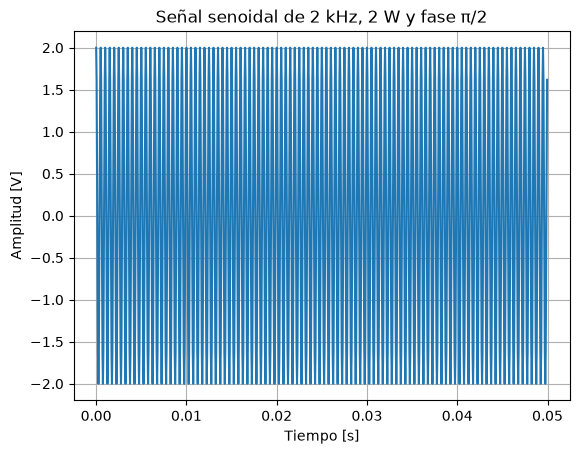

In [209]:
plt.figure()
plt.plot(n, xx)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal de 2 kHz, 2 W y fase π/2")
plt.show()

En el dominio del tiempo la señal mantiene la misma frecuencia, pero ahora alcanza valores entre -2 V y 2 V. El desfase de pi/2 desplaza la señal respecto de la senoide del punto anterior, sin modificar su frecuencia ni su potencia media.

In [210]:
# Hacemos la FFT
XX = np.fft.fft(xx)

mod_XX = np.abs(XX)

freq = np.fft.fftfreq(N, d=1/fs)

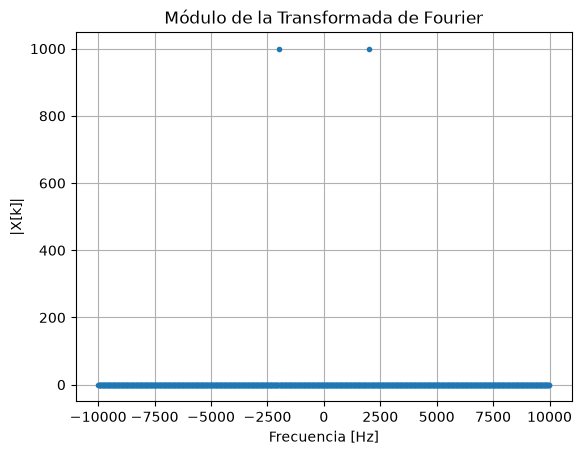

In [211]:
plt.figure()
plt.plot(freq, mod_XX, '.')
plt.title("Módulo de la Transformada de Fourier")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X[k]|")
plt.grid()
plt.show()

Punto 3:

En este punto se generaron N=1000 muestras de ruido con distribución normal, valor medio igual a 0 V y varianza 0.1.
Una distribución normal queda determinada por su media u y su desviación estándar.

Nuevamente se observan las componentes principales en +2000 Hz y -2000 Hz ya que el desfase no modifica la frecuencia de la señal.
La magnitud de los coeficientes es mayor que en el punto anterior debido a que la amplitud de la senoide aumentó de 1 a 2.

In [212]:
N = 1000
fs = 20000
var = 0.1

ruido = np.random.normal(0, np.sqrt(var), N)

La función np.random.normal() genera los valores aleatorios. El primer parámetro corresponde a la media, el segundo a la desviación estándar y el tercero a la cantidad de muestras.

In [213]:
media = np.mean(ruido)
varianza = np.var(ruido)

print("Media:", media)
print("Varianza:", varianza)

Media: 0.0007217961625477365
Varianza: 0.09724100209255711


Se calcularon la media y la varianza de las 1000 muestras para verificar la señal generada. Como se trata de una secuencia aleatoria finita, los resultados son cercanos a 0 y 0.1, pero no necesariamente exactamente iguales.

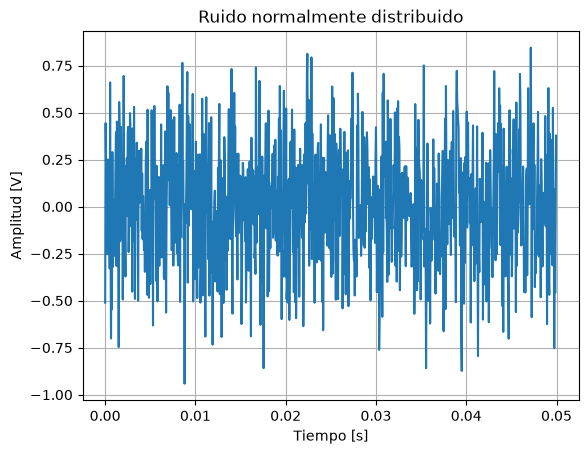

In [214]:
n = np.arange(N) / fs

plt.figure()
plt.plot(n, ruido)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Ruido normalmente distribuido")
plt.show()

En el dominio del tiempo se observa una señal aleatoria que varía alrededor de cero y no presenta un comportamiento periódico definido.

Pasamos a la FFT:

In [215]:
RR = np.fft.fft(ruido)

mod_RR = np.abs(RR)

freq = np.fft.fftfreq(N, d=1/fs)

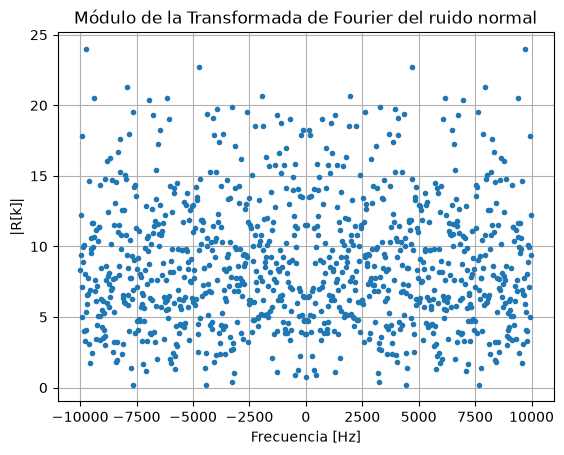

In [216]:
plt.figure()
plt.plot(freq, mod_RR, '.')
plt.title("Módulo de la Transformada de Fourier del ruido normal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|R[k]|")
plt.grid()
plt.show()

A diferencia de la señal senoidal, el espectro del ruido no presenta dos picos definidos en una frecuencia determinada. Las componentes aparecen distribuidas en un rango amplio de frecuencias, dando como resultado un espectro irregular.

Al tratarse de una única realización aleatoria de 1000 muestras, no esperamos obtener un espectro perfectamente uniforme.

Punto 4:

En este punto se generaron N=1000 muestras de ruido con distribución uniforme, valor medio igual a 0 V y varianza 0.1.

In [217]:
N = 1000
fs = 20000
var = 0.1

V = np.sqrt(3*var)

ruido = np.random.uniform(-V, V, N)

La función np.random.uniform() genera valores aleatorios con la misma probabilidad dentro del intervalo indicado.

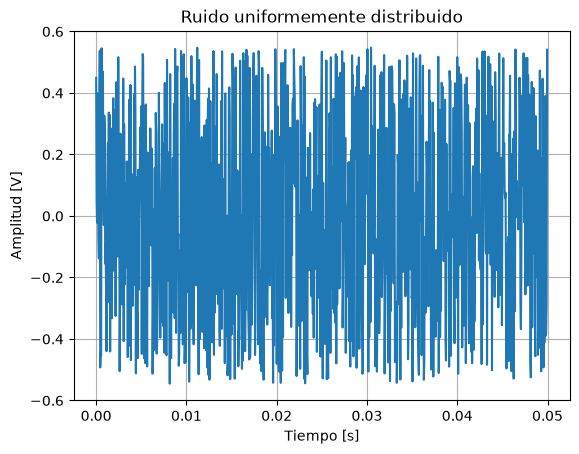

In [218]:
n = np.arange(N) / fs

plt.figure()
plt.plot(n, ruido)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Ruido uniformemente distribuido")
plt.show()

En el dominio del tiempo se observa una secuencia aleatoria cuyos valores permanecen dentro del intervalo definido. A diferencia del ruido normal, los valores dentro de ese intervalo tienen la misma probabilidad de aparecer.

FFT:

In [219]:
RR = np.fft.fft(ruido)

mod_RR = np.abs(RR)

freq = np.fft.fftfreq(N, d=1/fs)

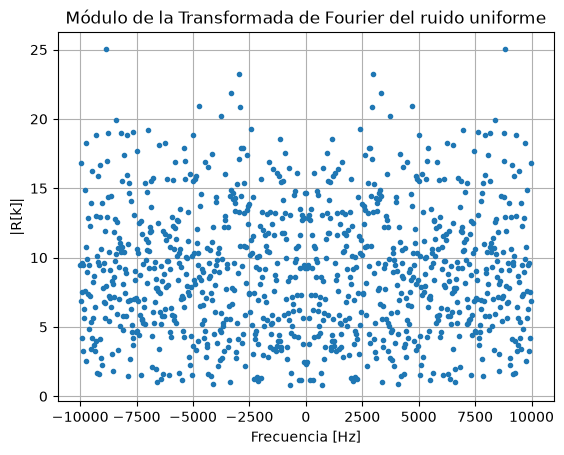

In [220]:
plt.figure()
plt.plot(freq, mod_RR, '.')
plt.title("Módulo de la Transformada de Fourier del ruido uniforme")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|R[k]|")
plt.grid()
plt.show()

Al igual que en el ruido normalmente distribuido, no se observan picos definidos en una frecuencia particular. El contenido frecuencial aparece distribuido en muchas frecuencias y el espectro presenta una forma irregular.

La principal diferencia entre ambos tipos de ruido se encuentra en cómo se distribuyen sus amplitudes en el dominio del tiempo.

Punto 5:

En este punto se generó una señal rectangular con la misma frecuencia de los primeros puntos 2 kHz, una potencia media de 1 W y un ciclo de actividad del 50%.

In [221]:
from scipy import signal

N = 1000
fs = 20000
f0 = 2000

n = np.arange(N) / fs

xx_rectangular = signal.square(2*np.pi*f0*n, duty=0.5)

Para generar la señal se utilizó signal.square(). El parámetro duty = 0.5 establece un ciclo de actividad del 50%. La función genera por defecto valores entre +1 y -1, por lo que ya se obtiene la amplitud necesaria para una potencia media de 1 W.

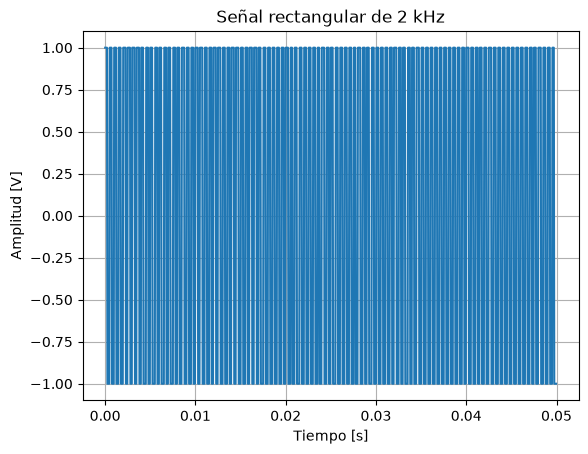

In [222]:
plt.figure()
plt.plot(n, xx_rectangular)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal rectangular de 2 kHz")
plt.show()

En el gráfico se observa la señal alternando entre +1 y -1. Al igual que en la senoide, se tienen muchos períodos dentro de las 1000 muestras, por lo que al graficarlos todos juntos la señal se ve muy comprimida.

In [223]:
rec = np.fft.fft(xx_rectangular)

mod_rec = np.abs(rec)

freq = np.fft.fftfreq(N, d=1/fs)

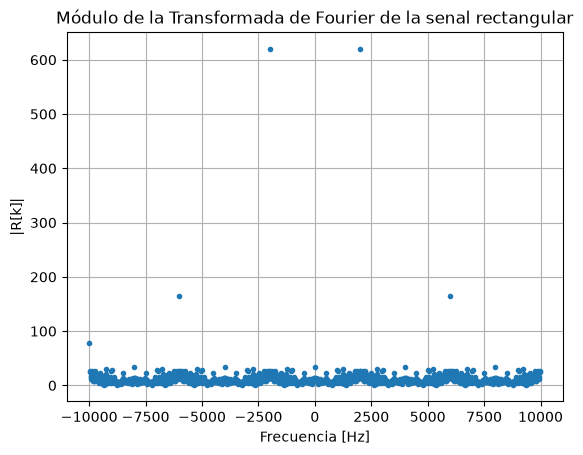

In [224]:
plt.figure()
plt.plot(freq, mod_rec,'.')
plt.title("Módulo de la Transformada de Fourier de la senal rectangular")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|R[k]|")
plt.grid()
plt.show()

En el espectro aparece la frecuencia fundamental en +/- 2000 Hz, pero a diferencia de una senoide también aparecen componentes en otras frecuencias.
Esto ocurre porque una señal rectangular puede representarse como una suma de varias componentes sinusoidales. Para un ciclo de actividad del 50% aparecen principalmente los armónicos impares.
Por eso observo componentes en 2000 Hz, 6000 Hz y alrededor de 10000 Hz. La última coincide con la frecuencia de Nyquist para fs = 20000 Hz

Punto 6:

Como señal adicional disponible en scipy.signal se utilizó el impulso unitario. Esta secuencia vale 1 en una única muestra y 0 en todas las demás 0

In [225]:
N = 1000

pulso = signal.unit_impulse(N)
pulso_desplazado = signal.unit_impulse(N, idx=4)

n = np.arange(N)

También genere una versión desplazada cuatro muestras

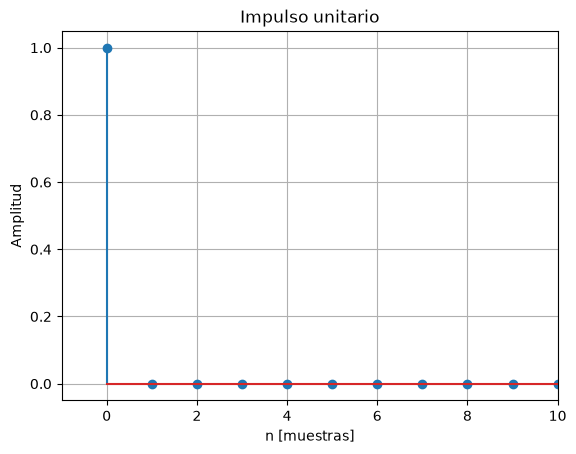

In [226]:
plt.figure()
plt.stem(n, pulso)
plt.xlim(-1, 10)
plt.grid()
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.title("Impulso unitario")
plt.show()

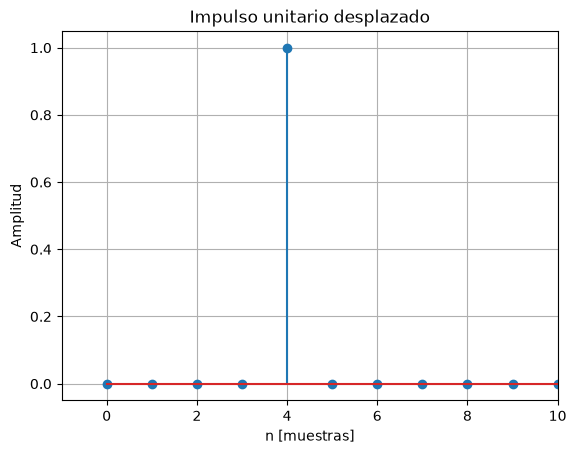

In [227]:
plt.figure()
plt.stem(n, pulso_desplazado)
plt.xlim(-1, 10)
plt.grid()
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.title("Impulso unitario desplazado")
plt.show()

En el primer caso el único valor distinto de cero se encuentra en n=0. En el segundo, el impulso se desplazó hasta n=4. 
Limite el eje horizontal para poder distinguir claramente el desplazamiento, ya que la secuencia completa contiene 1000 muestras.

El Teorema de Parseval permite relacionar una señal en el dominio del tiempo con su representación en frecuencia.

In [228]:
P_tiempo = np.mean(xx**2)

XX = np.fft.fft(xx)
mod_XX = np.abs(XX)

P_fft = np.sum(mod_XX**2) / N**2

print("Potencia en el tiempo:", P_tiempo)
print("Potencia mediante FFT:", P_fft)

Potencia en el tiempo: 1.9999999999999991
Potencia mediante FFT: 2.0


Los dos métodos entregan aproximadamente 2 W, verificando que la potencia media puede calcularse tanto a partir de las muestras de la señal en el tiempo como a partir de los coeficientes de su Transformada de Fourier.
De esta manera, Parseval permite comprobar que la información relacionada con la potencia se conserva al pasar del dominio temporal al dominio frecuencial.

A lo largo del trabajo se pudieron generar y analizar distintos tipos de señales en Python, observando tanto su comportamiento en el tiempo como su representación en frecuencia mediante la Transformada de Fourier. Se trabajó con señales senoidales, ruido normal y uniforme, y una señal rectangular, comparando las diferencias que aparecen en sus espectros.

También se pudo relacionar la amplitud de las señales con su potencia y comprobar, mediante el Teorema de Parseval, que la potencia puede obtenerse tanto desde el dominio temporal como desde el dominio frecuencial. 
En general, el trabajo permitió relacionar los conceptos teóricos vistos en clase con su implementación y visualización en Python.